In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy import nan
%run opentable.ipynb
plt.rcParams["figure.figsize"] = (15,2)



path_order = "/data2/run/data_zl/orders.csv"
path_nps = "/data2/run/data_zl/nps.csv"

sids = [
    {"exchange":"okxswap", "sid":0},
    {"exchange":"binanceswap", "sid":1},
    {"exchange":"bybitswap", "sid":2},
    {"exchange":"binancespot", "sid":3},
    {"exchange":"okxspot", "sid":4}
]

ks_file = [
    {"exchange":"okxswap", "ttype":"maker", "fee":-0.00005},
    {"exchange":"okxswap", "ttype":"taker", "fee":0.00015},
    {"exchange":"binanceswap", "ttype":"maker", "fee":-0.00005},
    {"exchange":"binanceswap", "ttype":"taker", "fee":0.00015},
    {"exchange":"bybitswap", "ttype":"maker", "fee":-0.0001},
    {"exchange":"bybitswap", "ttype":"taker", "fee":0.00025},
    {"exchange":"binancespot", "ttype":"maker", "fee":-0.00004},
    {"exchange":"binancespot", "ttype":"taker", "fee":0.00018},
    {"exchange":"okxspot", "ttype":"maker", "fee":-0.00005},
    {"exchange":"okxspot", "ttype":"taker", "fee":0.0002},
]


# ks_file = [
#     {"exchange":"okxswap", "ttype":"maker", "fee":-0.00005},
#     {"exchange":"okxswap", "ttype":"taker", "fee":0.00015},
#     {"exchange":"binanceswap", "ttype":"maker", "fee":0},
#     {"exchange":"binanceswap", "ttype":"taker", "fee":0.00015},
#     {"exchange":"bybitswap", "ttype":"maker", "fee":0},
#     {"exchange":"bybitswap", "ttype":"taker", "fee":0.00025},
#     {"exchange":"binancespot", "ttype":"maker", "fee":0},
#     {"exchange":"binancespot", "ttype":"taker", "fee":0.00018},
#     {"exchange":"okxspot", "ttype":"maker", "fee":0},
#     {"exchange":"okxspot", "ttype":"taker", "fee":0.0002},
# ]

In [27]:
norder = pd.read_csv(path_order, header = None)
norder.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,ask_m_1_0.0004_48,1701907301000,1701907305675,ask_m_1_0.0004_48,ARBUSDT,maker,1,sell,1.0623,75.347304,75.347304,filled,6109.728703,7456.8,ask:0.0004,1.0616,1.0617
1,bid_m_0_0.0002_74,1701907392000,1701907392636,bid_m_0_0.0002_74,ARBUSDT,maker,0,buy,1.0591,78.022455,78.022455,filled,328.726152,439.0,bid:0.0002,1.0592,1.0593
2,bid_m_0_0.0004_75,1701907392000,1701907392761,bid_m_0_0.0004_75,ARBUSDT,maker,0,buy,1.0589,78.022455,78.022455,filled,60.000000,377.0,bid:0.0004,1.0589,1.0590
3,bid_m_0_0.0002_115,1701907469000,1701907469971,bid_m_0_0.0002_115,ARBUSDT,maker,0,buy,1.0579,72.906583,10.000000,partial_filled,0.000000,1.0,bid:0.0002,1.0579,1.0580
4,ask_m_1_0.0002_131,1701907503000,1701907505397,ask_m_1_0.0002_131,ARBUSDT,maker,1,sell,1.0602,78.509194,78.509194,filled,895.649691,7935.1,ask:0.0002,1.0601,1.0602


In [28]:
norder.columns = ["oid", "cts", "uts", "oid2", "symbol", "ttype", "sid", "side", "price", "amount", "famount", "status", "inpos", "tlen","bid1","ask1","fkey"]
norder.groupby("symbol").count()

,oid,cts,uts,oid2,ttype,sid,side,price,amount,famount,status,inpos,tlen,bid1,ask1,fkey
symbol,,,,,,,,,,,,,,,,
ARBUSDT,35890,35890,35890,35890,35890,35890,35890,35890,35890,35890,35890,35890,35890,35890,35890,35890


In [29]:
nsid = pd.DataFrame(sids)
norder = pd.merge(norder, pd.DataFrame(sids), on="sid", how="left")
norder = pd.merge(norder, pd.DataFrame(ks_file), on=["exchange", "ttype"], how="left").sort_values("uts").reset_index()

In [30]:
norder.head()
norder["amount_trade"] = norder["famount"]
norder["amountu"] = norder["amount_trade"] * norder["price"]


In [31]:
norder.groupby("symbol").count()

,index,oid,cts,uts,oid2,ttype,sid,side,price,amount,...,status,inpos,tlen,bid1,ask1,fkey,exchange,fee,amount_trade,amountu
symbol,,,,,,,,,,,,,,,,,,,,,
ARBUSDT,35890,35890,35890,35890,35890,35890,35890,35890,35890,35890,...,35890,35890,35890,35890,35890,35890,35890,35890,35890,35890


In [32]:
norder.groupby("ttype").sum()["amountu"]

ttype
maker    1.501620e+06
Name: amountu, dtype: float64

In [33]:
ot = Opentable()
pfix = 0
ps = []
poss = {0:0,1:0,2:0,3:0,4:0}


for row in norder.sort_values("cts").to_dict("records"):
    #if row["status"] == "partial_filled":continue
    
    if(row["side"] == "buy"):
        p = ot.add("bid", row["price"], row["amount_trade"], row["cts"])
        pfix+=p
        poss[row["sid"]]+=(row["price"] * row["amount_trade"])
        pfix-=(row["fee"] * row["price"] * row["amount_trade"])
    if(row["side"] == "sell"):
        p = ot.drop("ask", row["price"], row["amount_trade"], row["cts"])
        pfix+=p
        poss[row["sid"]]-=(row["price"] * row["amount_trade"])
        pfix-=(row["fee"] * row["price"] * row["amount_trade"])
    openrisk,_l,_l = ot.get_openrisk()
        
    ps.append({
        "ts":row["cts"],
        "pfix":pfix,
        "open":openrisk,
        "poss_0":poss[0],
        "poss_1":poss[1],
        "poss_2":poss[2],
        "poss_3":poss[3],
        "poss_4":poss[4],
    })
    
    
    
    
    
    

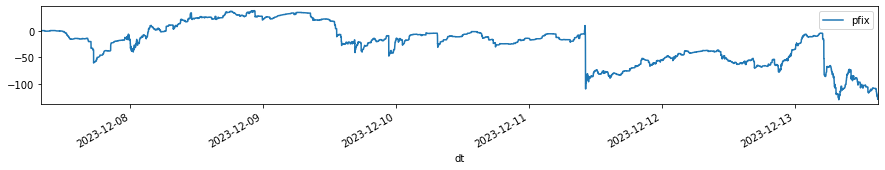

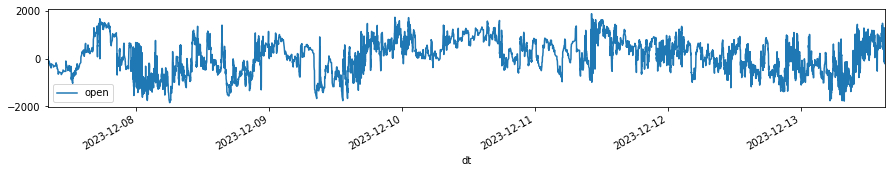

In [34]:
nps = pd.DataFrame(ps)
nps["dt"] = pd.to_datetime(nps["ts"] + 8*3600*1000, unit="ms")
nps.plot(x="dt", y="pfix")
nps.plot(x="dt", y="open")


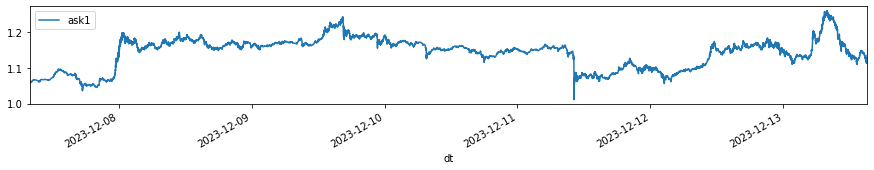

In [35]:
norder["dt"] = pd.to_datetime(norder["uts"] + 8*3600*1000, unit="ms")
norder.plot(x="dt", y="ask1")

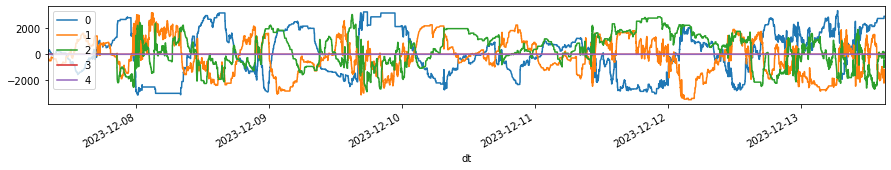

In [36]:
ax = nps.plot(x="dt", y="poss_0", label="0")
nps.plot(x="dt", y="poss_1", label="1", ax=ax)
nps.plot(x="dt", y="poss_2", label="2", ax=ax)
nps.plot(x="dt", y="poss_3", label="3", ax=ax)
nps.plot(x="dt", y="poss_4", label="4", ax=ax)

plt.legend()


In [37]:
nps = pd.read_csv(path_nps, header = None)
nps.columns = ["ts", "symbol", "sid", "pos", "open"]
nps["dt"] = pd.to_datetime(nps["ts"] + 8*3600*1000, unit="ms")


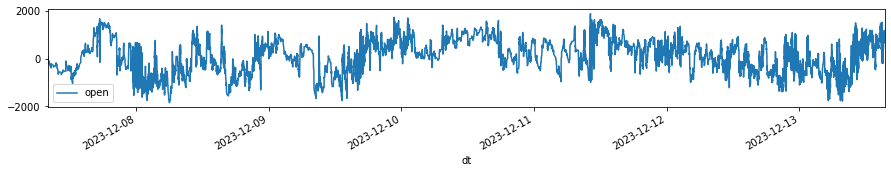

In [38]:
nps.plot(x="dt", y="open")

In [42]:
norder["amountu"].sum() / 3000/3,norder["amountu"].sum()

(166.8466965352409, 1501620.2688171682)

In [40]:
# #read tick
# tickpath  ="/data2/zl/l2_trade/tickfactor/SOLUSDT.npy"
# ntick = np.load(tickpath, allow_pickle=True)
# cols = ["ts"]
# for ks in sids:
    
#     cols.append("f_"+str(ks["sid"]))
#     cols.append("s_"+str(ks["sid"]))
# dftick = pd.DataFrame(ntick)
# dftick.columns = cols
# dftick["dt"] = pd.to_datetime(dftick["ts"], unit="s")

In [41]:
# norder["dt"] = pd.to_datetime(norder["cts"], unit="ms")
# for ks in sids:
#     torder = norder[norder["sid"] == ks["sid"]]
#     torder.plot(x="dt", y="price")